## Time series modelling
In this example we will analyse a time series by estimating its functional components: trend, seasonality, and offset. The observation equation for this time series follows the mathematical respresentation:

$$
Y(t) = y_0 + r t + a \cos(2\pi f_1t) + b\sin(2\pi f_1t) + o {u_k(t)} + \epsilon(t)
$$

with time $t$ in days.

We will follow these steps:

1. Plot the time series and visually identify its components;

2. Estimate the linear trend (intercept $y_0$ and rate $r$), and the offset $o$;

3. Remove the linear trend and offset from the time series;

4. Estimate the frequency $f_1$ of the seasonal component using the Power Spectral Density (PSD) of the time series (without linear trend and offset);

5. Estimate all components of the observation equation: $y_0$, $r$, $a$, $b$, $o$.


Note that in order to compute the PSD and estimate the dominant frequency $f_1$ of the seasonal component (Step 4), we must first **detrend** the time series (Steps 2 and 3), i.e., the linear trend and offset must be removed.

Once the dominant frequency is determined, all the components of the time series can be estimated (Step 5). If the time series has no seasonal component, Steps 2, 3 and 4 are not required.

### Step 1: Load data and plot
In the following code we plot the time series. From the plot, we can clearly identify a linear trend, seasonality, and an offset. Additionally, we know that the offset occurs at $t=270$ days due to a change in the data collection sensor.


In [1]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt

# Import the data
data = np.array([11.45597157, 15.94789764, 12.30148271,  9.13358141,  2.58184562,
       10.95456964,  3.69809318, 11.44636424, 10.80544783, 12.38098492,
       11.54897375, 19.31194611, 12.12252661,  9.98599556, 11.60389914,
       10.46209933,  8.96147123,  7.11245384,  4.26347084, 10.7519177 ,
        7.81589454, 16.66295892, 18.48344424, 17.5974714 , 13.2228174 ,
       16.31125138, 12.33660561,  2.33154242,  2.93452744,  9.13964713,
        8.36681806,  8.98550456, 13.99953011, 14.12102914, 19.83967076,
       18.05770602, 16.81519874, 10.84129196,  6.11617555, 10.70419501,
        9.99589668,  6.14546554, 11.77688896, 11.10459271, 14.3101019 ,
       18.02580669, 25.48864304, 21.63665269, 14.34135119, 16.76686106,
       13.47714406, 11.94351168, 10.78873477, 10.59644265,  6.60760718,
       12.68881244, 18.96558167, 21.35281324, 22.04885378, 21.05606879,
       12.58249621, 15.33167125, 17.28303595,  4.09987902, 13.08452483,
       19.53672184, 14.65426035, 18.03419113, 22.53381169, 21.38477433,
       25.03150635, 14.36365534, 17.91128252, 23.20698379, 20.33601078,
       17.13460094, 15.92905078, 11.47332787, 15.84490286, 22.24778677,
       22.42234145, 25.46102446, 27.27332887, 22.72454444, 19.48988589,
       17.22496605, 16.82470942, 15.6172585 , 12.88341355, 10.06804755,
       19.27404251, 20.06063283, 21.26023394, 23.63604259, 23.31337453,
       16.49804107, 23.65583924, 20.63226704, 17.81420825, 20.33008935,
       12.32074957, 18.06214985, 22.12335576, 22.14170638, 25.35997315,
       24.16451389, 27.45449635, 22.1276958 , 21.1225919 , 25.75348599,
       21.3301569 , 16.00975066, 14.13981402, 16.80413373, 26.24239636,
       24.28698747, 28.1689711 , 25.07763479, 24.85185391, 25.73729435,
       25.46118482, 26.69798825, 15.52087717, 14.28426396, 14.6935964 ,
       24.01857145, 25.89839835, 20.87540699, 27.11000048, 27.70532329,
       29.75270489, 22.95154796, 17.93809626, 17.12560764, 25.4752212 ,
       21.2062299 , 20.62191849, 22.02207213, 23.14056749, 27.28265646,
       30.03630198, 30.87332825, 29.68505463, 23.18109553, 23.10760677,
       24.6859994 , 17.73793252, 21.23716515, 22.55773239, 24.68434915,
       30.5539557 , 28.20042491, 29.86457394, 29.64903893, 29.87558983,
       25.44145766, 25.15128924, 21.75098338, 22.4843817 , 19.33684734,
       23.80925989, 24.9061194 , 24.61038011, 30.64163941, 28.31755917,
       36.32319151, 27.88528602, 36.65099753, 24.35778143, 31.66056825,
       21.55999167, 24.0877411 , 23.91592159, 27.17407354, 22.38060053,
       30.05883444, 29.13173921, 32.48554106, 29.90306969, 23.73822464,
       26.77315697, 25.67583368, 24.59395502, 23.01646767, 30.7258133 ,
       28.4909835 , 26.33665084, 32.10337929, 32.25584843, 37.21282467,
       32.84297716, 27.19689338, 26.78998349, 25.67384565, 20.14723868,
       27.35869997, 24.26742206, 30.8019133 , 31.66529389, 32.97336876,
       33.8577623 , 36.78463913, 29.45295741, 25.85279108, 26.60454342,
       24.71411438, 19.93564663, 25.71481838, 25.79991399, 31.41324447,
       36.83235238, 32.60684507, 37.18868723, 38.96180298, 32.54094749,
       25.88625055, 29.15889181, 31.86416904, 30.40862388, 33.57578034,
       29.13713622, 29.35594449, 36.24120669, 38.10897434, 37.94122838,
       35.84574435, 32.21622382, 33.9304986 , 29.18851557, 28.42731942,
       25.00423572, 35.09645178, 32.84900925, 31.32617723, 32.81378915,
       37.29071177, 37.53783153, 43.29440974, 35.59607042, 27.53980752,
       30.49041655, 31.19793188, 30.4689153 , 30.03845169, 35.01211804,
       30.85010531, 39.50696476, 43.72093536, 46.44965595, 35.85033201,
       39.13345467, 38.53149985, 26.19354375, 26.44781018, 26.80799059,
       30.97722805, 36.64374683, 34.37789527, 41.45921651, 39.04985636,
       37.06862959, 42.51144145, 37.29525277, 33.13879613, 33.13058898,
       27.6504018 , 32.00276581, 37.19959292, 31.64418287, 37.85890413,
       50.64455723, 53.26189276, 44.16929211, 49.08965557, 42.36165314,
       39.82915646, 44.60481335, 38.69534586, 42.77630437, 47.59814922,
       48.71239135, 50.36431533, 51.88045129, 52.89177835, 49.29070895,
       53.57511182, 44.31260359, 50.20744251, 41.37338282, 46.03992489,
       46.97807129, 47.75535531, 49.97741155, 54.30628047, 57.65448273,
       57.44782946, 49.09053715, 49.81219695, 46.72417144, 46.0311564 ,
       45.04752322, 44.60645396, 47.17987572, 52.30262242, 48.06727738,
       57.13731006, 56.26380265, 57.83153857, 56.75468076, 54.71784953,
       51.742382  , 47.45045687, 41.79072237, 49.53881885, 50.13675035,
       52.600372  , 54.61455211, 58.88523455, 57.86827682, 58.4039786 ,
       56.33625311, 55.87615159, 54.03660964, 44.936906  , 51.49690003,
       47.19675691, 51.27874422, 52.12747669, 53.68196493, 57.03014303,
       58.13588317, 60.45585654, 55.91280909, 49.46168341, 54.35719872,
       49.61442916, 49.04766705, 48.65478854, 50.32448206, 59.89094014,
       58.9865658 , 58.86774878, 52.87718759, 55.28051877, 60.92536613,
       55.92265   , 46.16703477, 49.6700841 , 52.35785335, 50.59231923,
       51.59957118, 55.84467833, 60.15888731, 63.27692528, 62.84108402,
       60.74284195, 61.88019549, 53.30303293, 57.45246017, 48.85485823,
       51.76801057, 50.73668764, 52.82848916, 55.19734302, 60.2669935 ,
       66.38470358, 59.73272987, 62.27745923, 62.432064  , 54.43587371,
       54.85934313, 46.43824379, 57.96466491, 55.77932624, 60.60174465,
       59.65298416, 56.62211788, 67.36302633, 66.27148442, 57.95151434,
       63.74746697, 52.54036198, 50.40561031, 59.24355332, 56.80434129,
       55.95082734, 60.31745782, 60.39747463, 60.4767769 , 62.5935966 ,
       59.81834154, 58.70264969, 63.8950646 , 57.36403968, 51.81715415,
       58.33809794, 51.12632774, 57.49079346, 63.48887669, 59.52374639,
       67.49671164, 62.28309287, 65.66098114, 64.65925981, 66.81293494,
       61.19720923, 55.48751692, 51.60104992, 53.96826095, 56.58452635,
       59.34553001, 67.65229591, 65.75424793, 65.65632486, 65.99148085,
       65.44853708, 60.50694571, 61.19993821, 60.12364375, 59.93184649,
       63.48731119, 61.12350502, 58.24920452, 65.8986243 , 63.64536901,
       63.79572593, 64.12001903, 62.14535278, 64.68425609, 56.90342646,
       61.57831818, 57.66321622, 63.72222826, 61.48417245, 66.02904428,
       65.32289511, 72.29778331, 69.87048382, 66.83200272, 62.6373197 ,
       61.73645523, 65.08488989, 61.04227702, 60.53522292, 55.77257358,
       65.45566672, 68.37357759, 71.94120313, 68.90744536, 68.54569404,
       69.92220244, 66.03327737, 58.38590875, 60.85068801, 58.80399466,
       66.63495512, 65.61470701, 67.62668741, 65.90517767, 70.52692682,
       69.66761933, 73.51037934, 67.74721527, 63.02629107, 62.17487742,
       61.19369148, 63.30270982, 61.92753578, 66.46761908, 67.8833176 ,
       68.33023079, 76.04517509, 74.44534732, 69.34495782, 69.45929329,
       65.25027491, 66.75228573, 60.42055774, 68.7378364 , 61.57801931,
       68.88936407, 65.84014135, 72.20553655, 74.03307371, 75.53317529,
       69.83744227, 69.6454565 , 67.24104963, 64.54883909, 61.37027826,
       68.15912383, 67.884073  , 67.77746262, 67.56149168, 68.15165627,
       65.45634875, 81.10033402, 73.18088532, 72.79922135, 70.53731861])
t = np.arange(0, len(data), 1)

 # Add an offset
data[270-1:] = data[270-1:]+10



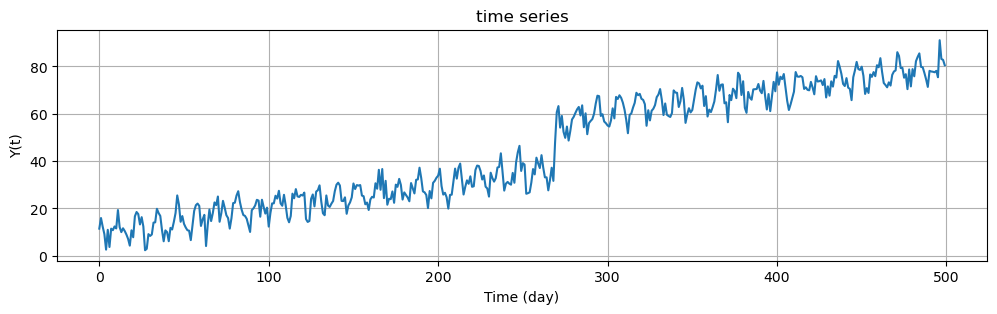

In [2]:
# Plot the data
plt.figure(figsize=(12, 3))
plt.plot(t, data, label="y_values")
plt.xlabel("Time (day)")
plt.ylabel("Y(t)")
plt.title("Time series")
plt.grid()

### Step 2 and 3: Estimate and Remove Linear Trend and Offset from the Time Series

To estimate the linear trend and offset we can use the unweighted Least Squares estimator since we don't know the covariance matrix of the data. This is equivalent to fitting a linear model to the time series.

The observation equation is written as:

$$
Y(t) = y_0 + r t + o {u_k(t)} + \epsilon(t).
$$

Therefore, the linear functional model for the $500$ observables is expressed as:

$$
\mathbb{E}(\underset{\mathrm{Y}}{\underbrace{\begin{bmatrix} Y_1 \\ \vdots \\ Y_{269}\\ Y_{270} \\ Y_{271} \\ \vdots \\ Y_{500} \end{bmatrix}}} )= \underset{\mathrm{A}}{\underbrace{\begin{bmatrix} 1 & t_1 & 0 \\ \vdots & \vdots & \vdots  \\ 1 & t_{269} & 0 \\ 1 & t_{270} & 1 \\  1 & t_{271} & 1 \\ \vdots & \vdots & \vdots \\  1 & t_{500} & 1\end{bmatrix}}}\underset{\mathrm{x}}{\underbrace{\begin{bmatrix} y_0 \\ r \\ o \end{bmatrix}}},
$$

and the least-squares solution of the unknown parameter vector $\mathrm{x}$ is obtained as:

$$
\mathrm{\hat{X}= (A^T A)^{-1} A^T \mathrm{Y}}.
$$

The time series without the linear trend and offset is simply the residuals:

$$
\mathrm{\hat{\epsilon}}= \mathrm{Y} - A\mathrm{\hat{Y}}.
$$

In the following code we estimate the linear trend and offset and remove them from the time series.

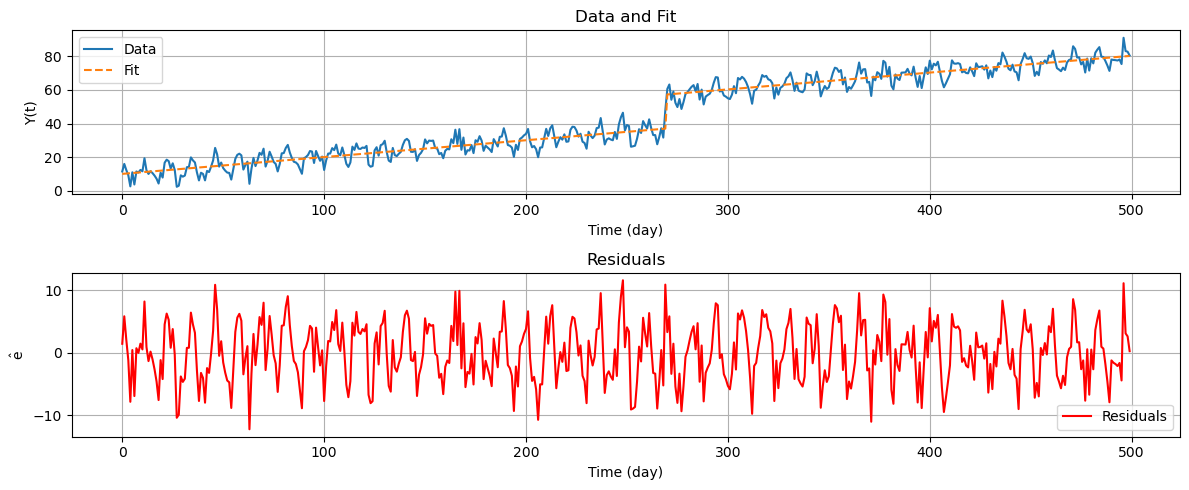

In [ ]:
offset = np.zeros_like(data)
offset[270:] = 1

A = np.column_stack((np.ones_like(t), t, offset))
xhat = np.linalg.solve(A.T @ A, A.T @ data)
yhat = A @ xhat
ehat = data - yhat

fig, axs = plt.subplots(2, 1, figsize=(12, 5))

# Plot data and fit
axs[0].plot(t, data, label='Data')
axs[0].plot(t, yhat, label='Fit', linestyle='--')
axs[0].set_xlabel('Time (day)')
axs[0].set_ylabel('Y(t)')
axs[0].set_title('Data and Fit')
axs[0].legend()
axs[0].grid()

# Plot residuals
axs[1].plot(t, ehat, label='Residuals', color='red')
axs[1].set_xlabel('Time (day)')
axs[1].set_ylabel('$\mathrm{\hat{\epsilon}}$')
axs[1].set_title('Residuals')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()



In the above plots the blue line represents the observed time series $\mathrm{Y}$, the dashed orange line is the fitted line using the previously defined functional model $\hat{\mathrm{Y}} = \mathrm{A}\hat{\mathrm{X}}$, i.e., the least squares estimate of the time series, and the red line represents the residuals $\mathrm{\hat{\epsilon}}$. We can identify a seasonal component in the residuals, meaning that they are not completely stationary. In the next step we will estimate this seasonal component.  

### Step 4: Estimate the frequency $f_1$ of the seasonal component
We aim to find the dominant frequency of the seasonal component by analyzing the Power Spectral Density (PSD) of the time series. Based on the section of [spectral estimation](spectral_estim), we can obtain the PSD using the following code.

Frequency corresponding to the highest peak: 0.084


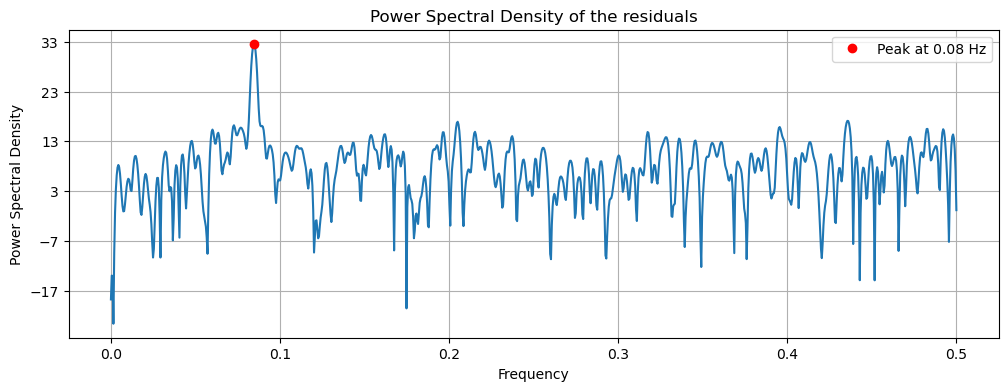

In [13]:
# Create a sample signal
N = len(data)  # Number of points
T = 500/N  # Sampling interval (1000 Hz sampling rate)

plt.figure(figsize=(12, 4))
# in plt.psd we have added NFFT=1024 and pad_to=2048 to get a better resolution
pxx, freqs, line = plt.psd(ehat, return_line=True, Fs=1, NFFT=1024, pad_to=2048)

# Find the frequency corresponding to the highest peak
peak_idx = np.argmax(pxx)
highest_peak_freq = freqs[peak_idx]
highest_peak_power = 10 * np.log10(pxx[peak_idx])
print("Frequency corresponding to the highest peak:", round(highest_peak_freq,3))

# Mark the peak with a red dot
plt.plot(highest_peak_freq, highest_peak_power, 'ro', label=f'Peak at {highest_peak_freq:.2f} Hz')

plt.xlabel("Frequency")
plt.ylabel("Power Spectral Density")
plt.title("Power Spectral Density of the residuals")
plt.grid(True)
plt.legend()


The dominant frequency can be idenfied from the PDF as the frequency with the highest power. In this case, the dominant frequency $f_1$ is 0.084.

Finally, we can include the seasonal component associated with the identified frequency in the functional model. For this, we need to add two more columns to matrix $\mathrm{A}$. Now, the functional model is expressed as:

$$
\mathbb{E}(\underset{\mathrm{Y}}{\underbrace{\begin{bmatrix} Y_1 \\ \vdots \\ Y_{269}\\ Y_{270} \\ Y_{271} \\ \vdots \\ Y_{500} \end{bmatrix}}} )= \underset{\mathrm{A}}{\underbrace{\begin{bmatrix} 1 & t_1 & 0 & \cos(2\pi t_{1} f_1) & \sin(2\pi t_{1} f_1)\\ \vdots & \vdots & \vdots & \vdots & \vdots  \\ 1 & t_{269} & 0 & \cos(2\pi t_{269} f_1) & \sin(2\pi t_{269} f_1) \\ 1 & t_{270} & 1 & \cos(2\pi t_{270} f_1) & \sin(2\pi t_{270} f_1)\\  1 & t_{271} & 1  & \cos(2\pi t_{271} f_1) & \sin(2\pi t_{271} f_1)\\ \vdots & \vdots & \vdots & \vdots & \vdots \\  1 & t_{500} & 1 & \cos(2\pi t_{500} f_1) & \sin(2\pi t_{500} f_1)\end{bmatrix}}}\underset{\mathrm{x}}{\underbrace{\begin{bmatrix} y_0 \\ r \\ o \\ a \\ b \end{bmatrix}}},
$$

We can again estimate the unknown vector $\mathrm{x}$, and obtain the residuals.

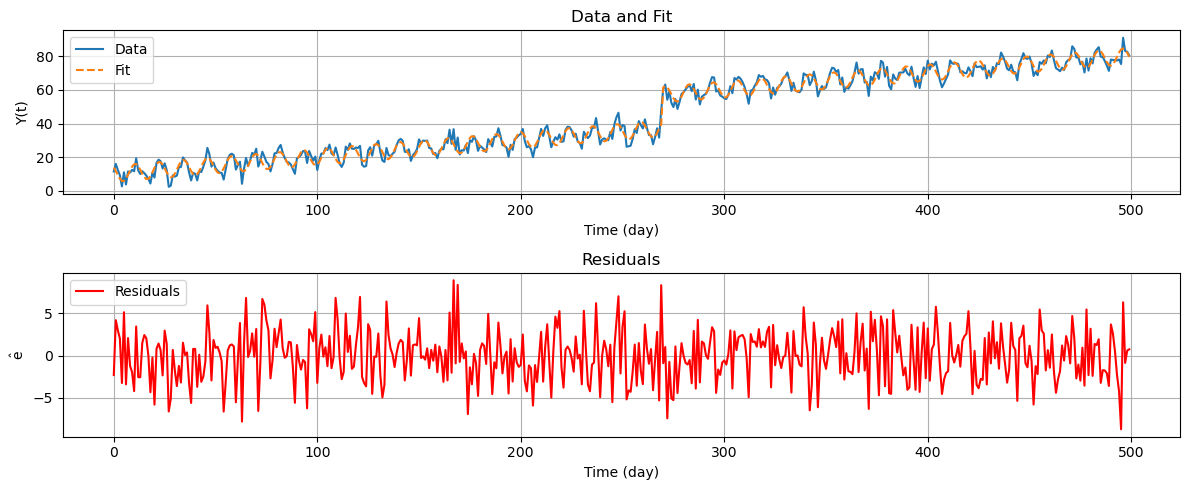

In [ ]:
f_1 = highest_peak_freq

A2 = np.column_stack((np.ones_like(t), t, offset, np.cos(2*np.pi*f_1*t), np.sin(2*np.pi*f_1*t)))

xhat2 = np.linalg.solve(A2.T @ A2, A2.T @ data)
yhat2 = A2 @ xhat2
ehat2 = data - yhat2 # removing the functional components from the data

fig, axs = plt.subplots(2, 1, figsize=(12, 5))

# Plot data and fit
axs[0].plot(t, data, label='Data')
axs[0].plot(t, yhat2, label='Fit', linestyle='--')
axs[0].set_xlabel('Time (day)')
axs[0].set_ylabel('Y(t)')
axs[0].set_title('Data and Fit')
axs[0].legend()
axs[0].grid()

# Plot residuals
axs[1].plot(t, ehat2, label='Residuals', color='red')
axs[1].set_xlabel('Time (day)')
axs[1].set_ylabel('$\mathrm{\hat{epsilon}}$')
axs[1].set_title('Residuals')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

In the above plots the blue line represents the time series $\mathrm{Y}$, the dashed orange line is the fitted line using the previously defined functional model $\hat{\mathrm{Y}} = \mathrm{A}\hat{\mathrm{X}}$, and the red line represents the residuals $\mathrm{\hat{\epsilon}}$. We have been able to remove the seasonal component from the residuals since now the residuals resemble white noise. 
